# Unified Inference Pipeline
Runs all 16 configurations (4 SigExt models x 2 Quantizations x 2 Shot types).
Workflow: Setup -> Config -> Inference -> Summary.

## 1. Setup

In [1]:
# Install deps
!pip install -q transformers datasets accelerate bitsandbytes sentence-transformers \
    spacy rouge_score bert_score langchain langchain-community langchain-huggingface \
    huggingface_hub 'numpy<2.0' 'scipy>=1.10' matplotlib seaborn

!python -m spacy download it_core_news_sm

      13.0/13.0 MB 26.8 MB/s  0:00:00 eta 0:00:01
 Download and installation successful
You can now load the package via spacy.load('it_core_news_sm')


In [2]:
import os
import gc
import torch
import json
import spacy
import numpy as np
from datetime import datetime
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForTokenClassification, 
    AutoModelForCausalLM, 
    BitsAndBytesConfig, 
    pipeline
)
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from huggingface_hub import login

# Load spacy for sentence segmentation
nlp = spacy.load("it_core_news_sm")

## 2. Configuration

In [3]:
# Auth
try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
except:
    HF_TOKEN = os.getenv("HF_TOKEN") or "YOUR_HF_TOKEN_HERE"

login(token=HF_TOKEN)

# SigExt models
SIGEXT_CONFIGS = {
    "10k-60t": {
        "model_id": "LookUpMark/sigext-wits-it-10k-060t",
        "skip_samples": 25000,
        "threshold": 0.60
    },
    "25k-60t": {
        "model_id": "LookUpMark/sigext-wits-it-25k-060t",
        "skip_samples": 25000,
        "threshold": 0.60
    },
    "25k-65t": {
        "model_id": "LookUpMark/sigext-wits-it-25k-065t",
        "skip_samples": 25000,
        "threshold": 0.65
    },
    "25k-70t": {
        "model_id": "LookUpMark/sigext-wits-it-25k-070t",
        "skip_samples": 25000,
        "threshold": 0.70
    }
}

# Quantization settings
QUANT_CONFIGS = {
    "4bit": {
        "load_in_4bit": True,
        "bnb_4bit_quant_type": "nf4",
        "bnb_4bit_compute_dtype": torch.float16,
        "bnb_4bit_use_double_quant": True
    },
    "8bit": {
        "load_in_8bit": True
    }
}

SHOT_TYPES = ["zero-shot", "few-shot"]

GLOBAL_CONFIG = {
    "llm_model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "num_test_samples": 100,
    "max_length": 2048,
    "output_dir": "./results"
}

os.makedirs(GLOBAL_CONFIG["output_dir"], exist_ok=True)

print(f"Configs: {len(SIGEXT_CONFIGS) * len(QUANT_CONFIGS) * len(SHOT_TYPES)}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Configs: 16


## 3. Prompts

In [4]:
PROMPT_TEMPLATES = {
    "zero-shot": """<|begin_of_text|><|start_header_id|>system<|end_header_id|>
Sei un esperto di sintesi testuale italiano. Il tuo compito è generare riassunti 
che siano:
- FEDELI: Non inventare informazioni non presenti nel testo
- COMPLETI: Includi tutti i concetti chiave indicati
- COERENTI: Il riassunto deve essere fluido e ben scritto
<|eot_id|><|start_header_id|>user<|end_header_id|>
TESTO ORIGINALE:
{source}

---

ISTRUZIONI OBBLIGATORIE:
I seguenti concetti chiave sono stati estratti dal testo e DEVONO essere 
riflessi nel riassunto finale:

{keyphrases}

---

Genera un riassunto astrattivo in italiano (150-250 parole):
<|eot_id|><|start_header_id|>assistant<|end_header_id|>""",

    "few-shot": """<|begin_of_text|><|start_header_id|>system<|end_header_id|>
# RUOLO
Sei un assistente editoriale esperto specializzato nella sintesi di testi complessi.

# OBIETTIVO
Generare riassunti astrattivi in Italiano che integrino perfettamente le informazioni salienti fornite (Frasi Chiave).

# VINCOLI E PRIMING
1. **Content Priming**: Le Frasi Chiave sono i pilastri del contenuto. Devono essere tutte presenti.
2. **Structural Priming**: Usa le Frasi Chiave come **scaletta logica** per strutturare il paragrafo.
3. **Stile**: Mantieni un tono formale, accademico e oggettivo.
4. **Formato**: Segui rigorosamente la struttura degli esempi forniti.
<|eot_id|><|start_header_id|>user<|end_header_id|>

### Esempio 1
Testo: "La rivista ''Huey, Dewey and Louie Junior Woodchucks'', che pubblicava le avventure delle Giovani Marmotte, per un certo periodo vide la collaborazione alternata ai testi di Jerry Siegel e Barks. Soprattutto il secondo, tornato in attività dopo essersi ufficialmente ritirato su richiesta di Chase Craig - a quel tempo curatore editoriale della Western Publishing - realizzò molte storie generalmente disegnate da altri artisti. In particolare questa venne disegnata da Kay Wright e pubblicata sul 12° numero della collana nel gennaio 1972. Ne venne poi realizzata una nuova versione dal disegnatore Daan Jippes pubblicata sul settimanale olandese ''Donald Duck'' il 27 marzo del 1992 e pubblicata in Italia come '''Le Giovani Marmotte e la danza tempestosa'''."
Frasi Chiave: Giovani Marmotte, Carl Barks, Kay Wright, 1972, Daan Jippes, 1992
Riassunto: "''Le Giovani Marmotte e la danza 'antiscolastica''' è una storia a fumetti scritta da Carl Barks e disegnata da Kay Wright. Venne pubblicata nel 1972, e Daan Jippes ne realizzò una nuova versione nel 1992."

### Esempio 2
Testo: "La ''Lega nazionale degli studenti greci in Italia'' venne fondata a Roma nel giugno del 1967, in seguito al colpo di Stato dei colonnelli greci del 21 aprile dello stesso anno. Ebbe sedi in tutte le principali città universitarie italiane. L'Esesi fu subito punto di riferimento della giunta militare golpista di Atene. Venne incaricata dell'attività propagandistica in favore del nuovo governo e della 'vigilanza morale sul credo nazionale degli studenti greci in Italia'."
Frasi Chiave: Lega nazionale degli studenti greci in Italia, regime dei colonnelli greci, movimento, Italia
Riassunto: "La Lega nazionale degli studenti greci in Italia fu un movimento operante in Italia a favore del regime dei colonnelli greci."

---

### TASK CORRENTE
Testo Originale:
{source}

Frasi Chiave (da usare come ossatura):
{keyphrases}

Genera il riassunto collegando logicamente i punti chiave:<|eot_id|><|start_header_id|>assistant<|end_header_id|>"""
}

## 4. Helpers

In [5]:
def get_test_data(skip_samples, num_samples):
    # Load held-out test set
    print(f"  Loading test data (skipping {skip_samples})...")
    
    dataset = load_dataset("silvia-casola/WITS", split="train", streaming=True)
    dataset = dataset.skip(skip_samples)
    
    test_data = []
    for entry in dataset:
        source = entry['source']
        summary = entry['summary']
        
        if len(source) < 500 or len(summary) < 50 or len(source) > 10000:
            continue
            
        test_data.append({"source": source, "reference": summary})
        
        if len(test_data) >= num_samples:
            break
    
    print(f"  Test data ready: {len(test_data)} samples")
    return test_data


def load_sigext_model(model_id):
    print(f"  Loading SigExt: {model_id}...")
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForTokenClassification.from_pretrained(model_id).to("cpu")
    return model, tokenizer


def load_llm(model_id, quant_config):
    quant_name = "4-bit" if "load_in_4bit" in quant_config else "8-bit"
    print(f"  Loading LLM ({quant_name}): {model_id}...")
    
    bnb_config = BitsAndBytesConfig(**quant_config)
    
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto"
    )
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    tokenizer.pad_token = tokenizer.eos_token
    
    return model, tokenizer


def create_chain(llm_model, llm_tokenizer, shot_type):
    pipe = pipeline(
        "text-generation",
        model=llm_model,
        tokenizer=llm_tokenizer,
        max_new_tokens=256,
        temperature=0.1
    )
    
    llm = HuggingFacePipeline(pipeline=pipe)
    template = PROMPT_TEMPLATES[shot_type]
    prompt = PromptTemplate(template=template, input_variables=["source", "keyphrases"])
    
    return prompt | llm | StrOutputParser()


def extract_salient_sentences(text, model, tokenizer, max_length):
    """
    Extract COMPLETE SENTENCES marked as salient by SigExt.
    """
    # Segment into sentences
    sentences = [sent.text.strip() for sent in nlp(text).sents if len(sent.text.strip()) > 20]
    
    if not sentences:
        return [], ""
    
    salient_sentences = []
    
    for sent in sentences:
        inputs = tokenizer(
            sent,
            return_tensors="pt",
            truncation=True,
            max_length=max_length
        ).to("cpu")
        
        with torch.no_grad():
            logits = model(**inputs).logits
        
        preds = torch.argmax(logits, dim=2)[0].tolist()
        
        valid_preds = preds[1:-1] if len(preds) > 2 else preds
        if valid_preds:
            salient_ratio = sum(valid_preds) / len(valid_preds)
            if salient_ratio > 0.5:
                salient_sentences.append(sent)
    
    keyphrases_text = "\n".join(f"- {s}" for s in salient_sentences)
    
    return salient_sentences, keyphrases_text


def preprocess_dataset(test_data, sigext_model, sigext_tokenizer, max_length):
    # Pre-extract salient sentences
    processed_data = []
    for item in tqdm(test_data, desc="    Extracting Salient Sentences"):
        salient_sents, keys_text = extract_salient_sentences(
            item['source'], sigext_model, sigext_tokenizer, max_length
        )
        processed_data.append({
            "source": item['source'],
            "reference": item['reference'],
            "salient_sentences": salient_sents,
            "keyphrases": keys_text
        })
    return processed_data


def run_evaluation(processed_data, chain):
    scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=True)
    metrics = {"bert": [], "rouge": [], "kir": []}
    samples = []  # Store per-sample details
    
    for item in tqdm(processed_data, desc="    Generating & Evaluating"):
        try:
            keys_text = item['keyphrases']
            salient_sents = item['salient_sentences']
            
            # Generate
            res = chain.invoke({"source": item['source'], "keyphrases": keys_text})
            gen_summary = res.split("assistant<|end_header_id|>")[-1].strip()
            
            # ROUGE-1
            rouge_score = scorer.score(item['reference'], gen_summary)['rouge1'].fmeasure
            metrics["rouge"].append(rouge_score)
            
            # BERTScore
            _, _, F1 = bert_score(
                [gen_summary], [item['reference']], lang="it", verbose=False
            )
            bert_sc = F1.mean().item()
            metrics["bert"].append(bert_sc)
            
            # KIR
            kir_score = 0.0
            if salient_sents:
                gen_lower = gen_summary.lower()
                hits = 0
                for sent in salient_sents:
                    words = [w.lower() for w in sent.split() if len(w) > 4]
                    if words:
                        word_hits = sum(1 for w in words if w in gen_lower)
                        if word_hits / len(words) > 0.3:
                            hits += 1
                kir_score = hits / len(salient_sents)
            metrics["kir"].append(kir_score)
            
            # Store sample details
            samples.append({
                "source": item['source'][:500] + "..." if len(item['source']) > 500 else item['source'],
                "reference": item['reference'],
                "salient_sentences": salient_sents,
                "generated_summary": gen_summary,
                "scores": {
                    "bert": float(bert_sc),
                    "rouge": float(rouge_score),
                    "kir": float(kir_score)
                }
            })
                
        except Exception as e:
            print(f"    Error: {e}")
            continue
    
    return metrics, samples


def save_results(metrics, samples, config_name, quant_name, shot_type, sigext_id, llm_id, num_samples, skip_samples, output_dir):
    results = {
        "run_info": {
            "timestamp": datetime.now().isoformat(),
            "config": config_name,
            "quantization": quant_name,
            "inference_type": shot_type,
            "sigext_model": sigext_id,
            "llm_model": llm_id,
            "num_test_samples": num_samples,
            "skip_train_samples": skip_samples
        },
        "metrics": {
            "bert_score": {
                "mean": float(np.mean(metrics['bert'])),
                "std": float(np.std(metrics['bert'])),
                "min": float(np.min(metrics['bert'])),
                "max": float(np.max(metrics['bert']))
            },
            "rouge1": {
                "mean": float(np.mean(metrics['rouge'])),
                "std": float(np.std(metrics['rouge'])),
                "min": float(np.min(metrics['rouge'])),
                "max": float(np.max(metrics['rouge']))
            },
            "kir": {
                "mean": float(np.mean(metrics['kir'])),
                "std": float(np.std(metrics['kir'])),
                "min": float(np.min(metrics['kir'])),
                "max": float(np.max(metrics['kir']))
            }
        },
        "raw_scores": {
            "bert": [float(x) for x in metrics['bert']],
            "rouge": [float(x) for x in metrics['rouge']],
            "kir": [float(x) for x in metrics['kir']]
        },
        "samples": samples
    }
    
    filename = f"results_{shot_type.replace('-', '_')}_{quant_name}_{config_name}.json"
    filepath = os.path.join(output_dir, filename)
    
    with open(filepath, 'w') as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
    
    return filepath, results


def clear_gpu_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

## 5. Evaluation Loop

In [6]:
# Main Loop
all_results = []
PREPROCESSED_DATA = {}

print("=" * 60)
print("PHASE 1: PRE-PROCESSING (SigExt Keyphrase Extraction)")
print("=" * 60)

for config_name, sigext_config in SIGEXT_CONFIGS.items():
    print(f"\n  --- Processing Config: {config_name} ---")
    
    # Load SigExt
    sigext_model, sigext_tokenizer = load_sigext_model(
        sigext_config["model_id"]
    )
    
    # Load data
    test_data = get_test_data(
        sigext_config["skip_samples"],
        GLOBAL_CONFIG["num_test_samples"]
    )
    
    # Extract keyphrases
    PREPROCESSED_DATA[config_name] = preprocess_dataset(
        test_data,
        sigext_model,
        sigext_tokenizer,
        GLOBAL_CONFIG["max_length"]
    )
    
    # Cleanup
    del sigext_model, sigext_tokenizer
    clear_gpu_memory()

print("=" * 60)
print("PHASE 2: INFERENCE (LLM Generation)")
print("=" * 60)

for quant_name, quant_config in QUANT_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"QUANTIZATION: {quant_name}")
    print(f"{'='*60}")
    
    # Load LLM
    clear_gpu_memory()
    llm_model, llm_tokenizer = load_llm(
        GLOBAL_CONFIG["llm_model_id"], 
        quant_config
    )
    
    for config_name, sigext_config in SIGEXT_CONFIGS.items():
        print(f"\n  --- SigExt Config: {config_name} ---")
        
        # Get pre-processed data
        processed_data = PREPROCESSED_DATA[config_name]
        
        for shot_type in SHOT_TYPES:
            print(f"\n    >> Running {shot_type} inference...")
            
            # Create chain
            chain = create_chain(llm_model, llm_tokenizer, shot_type)
            
            # Run
            metrics, samples = run_evaluation(
                processed_data,
                chain
            )
            
            # Save
            filepath, results = save_results(
                metrics,
                samples,
                config_name,
                quant_name,
                shot_type,
                sigext_config["model_id"],
                GLOBAL_CONFIG["llm_model_id"],
                GLOBAL_CONFIG["num_test_samples"],
                sigext_config["skip_samples"],
                GLOBAL_CONFIG["output_dir"]
            )
            
            # Add to summary
            all_results.append({
                "config": config_name,
                "quant": quant_name,
                "shot_type": shot_type,
                "bert": results["metrics"]["bert_score"]["mean"],
                "rouge": results["metrics"]["rouge1"]["mean"],
                "kir": results["metrics"]["kir"]["mean"]
            })
            
            print(f"    BERT: {results['metrics']['bert_score']['mean']:.4f} | "
                  f"ROUGE-1: {results['metrics']['rouge1']['mean']:.4f} | "
                  f"KIR: {results['metrics']['kir']['mean']:.2%}")
            print(f"    Saved: {filepath}")
            
            # Cleanup chain
            del chain
            gc.collect()
    
    # Cleanup LLM
    del llm_model, llm_tokenizer
    clear_gpu_memory()

print("=" * 60)
print("ALL EVALUATIONS COMPLETE!")
print("=" * 60)

PHASE 1: PRE-PROCESSING (SigExt Keyphrase Extraction)

  --- Processing Config: 10k-60t ---
  Loading SigExt: LookUpMark/sigext-wits-it-10k-060t...
  Loading test data (skipping 25000)...


Repo card metadata block was not found. Setting CardData to empty.


  Test data ready: 100 samples


    Extracting Salient Sentences:   0%|          | 0/100 [00:00<?, ?it/s]


  --- Processing Config: 25k-60t ---
  Loading SigExt: LookUpMark/sigext-wits-it-25k-060t...
  Loading test data (skipping 25000)...


...

    Generating & Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

Device set to use cuda:0


    BERT: 0.6590 | ROUGE-1: 0.2116 | KIR: 46.78%
    Saved: ./results/results_zero_shot_8bit_25k-70t.json

    >> Running few-shot inference...


    Generating & Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

    BERT: 0.6613 | ROUGE-1: 0.2158 | KIR: 43.90%
    Saved: ./results/results_few_shot_8bit_25k-70t.json

ALL EVALUATIONS COMPLETE!


## 6. Summary

In [7]:
# Print summary table
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"{'Config':<10} {'Quant':<6} {'Shot':<10} {'BERT':<8} {'ROUGE-1':<8} {'KIR':<8}")
print("-" * 40)

for r in sorted(all_results, key=lambda x: (x['config'], x['quant'], x['shot_type'])):
    print(f"{r['config']:<10} {r['quant']:<6} {r['shot_type']:<10} "
          f"{r['bert']:.4f}   {r['rouge']:.4f}   {r['kir']:.2%}")

# Save summary
summary_file = os.path.join(GLOBAL_CONFIG["output_dir"], "summary.json")
with open(summary_file, 'w') as f:
    json.dump(all_results, f, indent=2)

print("=" * 60)
print(f"Summary saved to: {summary_file}")


RESULTS SUMMARY
Config     Quant  Shot       BERT     ROUGE-1  KIR     
--------------------------------------------------------------------------------
10k-60t    4bit   few-shot   0.6619   0.2104   45.57%
10k-60t    4bit   zero-shot  0.6611   0.2109   48.96%
10k-60t    8bit   few-shot   0.6649   0.2176   43.96%
10k-60t    8bit   zero-shot  0.6592   0.2105   49.08%
25k-60t    4bit   few-shot   0.6628   0.2133   43.78%
25k-60t    4bit   zero-shot  0.6609   0.2093   47.12%
25k-60t    8bit   few-shot   0.6609   0.2087   43.43%
25k-60t    8bit   zero-shot  0.6610   0.2120   45.86%
25k-65t    4bit   few-shot   0.6612   0.2107   39.85%
25k-65t    4bit   zero-shot  0.6594   0.2080   45.76%
25k-65t    8bit   few-shot   0.6618   0.2128   41.76%
25k-65t    8bit   zero-shot  0.6594   0.2101   45.66%
25k-70t    4bit   few-shot   0.6623   0.2136   44.41%
25k-70t    4bit   zero-shot  0.6589   0.2093   47.77%
25k-70t    8bit   few-shot   0.6613   0.2158   43.90%
25k-70t    8bit   zero-shot  0.6590 

## 7. Analysis


  BEST CONFIGURATIONS BY METRIC

  Best BERT Score: 0.6649
   Config: 10k-60t | 8bit | few-shot

  Best ROUGE-1: 0.2176
   Config: 10k-60t | 8bit | few-shot

  Best KIR: 49.08%
   Config: 10k-60t | 8bit | zero-shot


  GENERATING PLOTS...
Saved: ./results/figures/comparison_bert.png


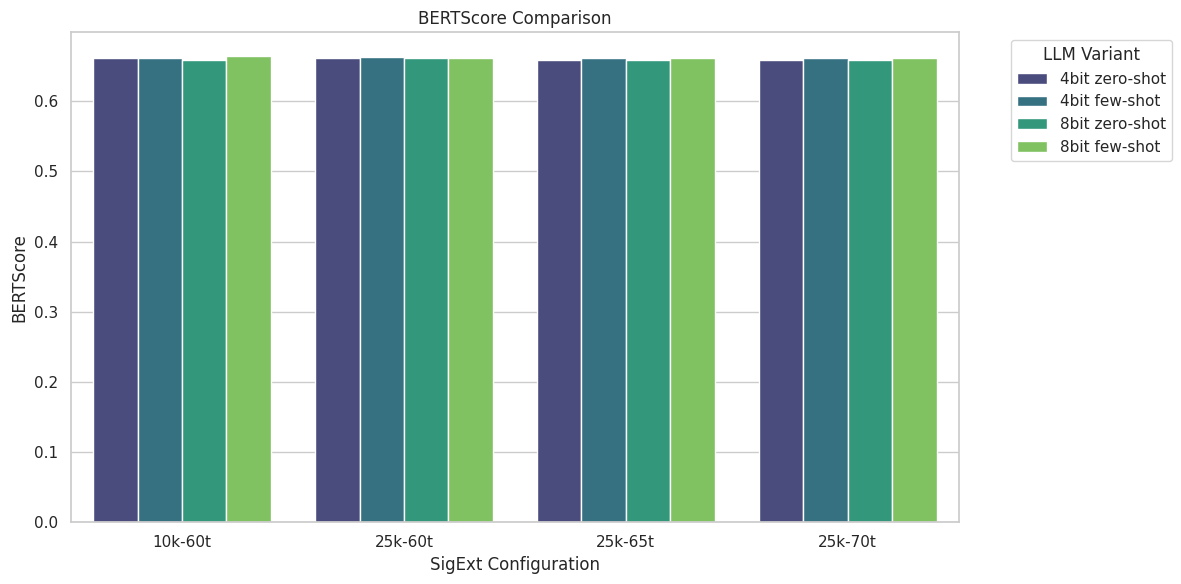

Saved: ./results/figures/comparison_rouge.png


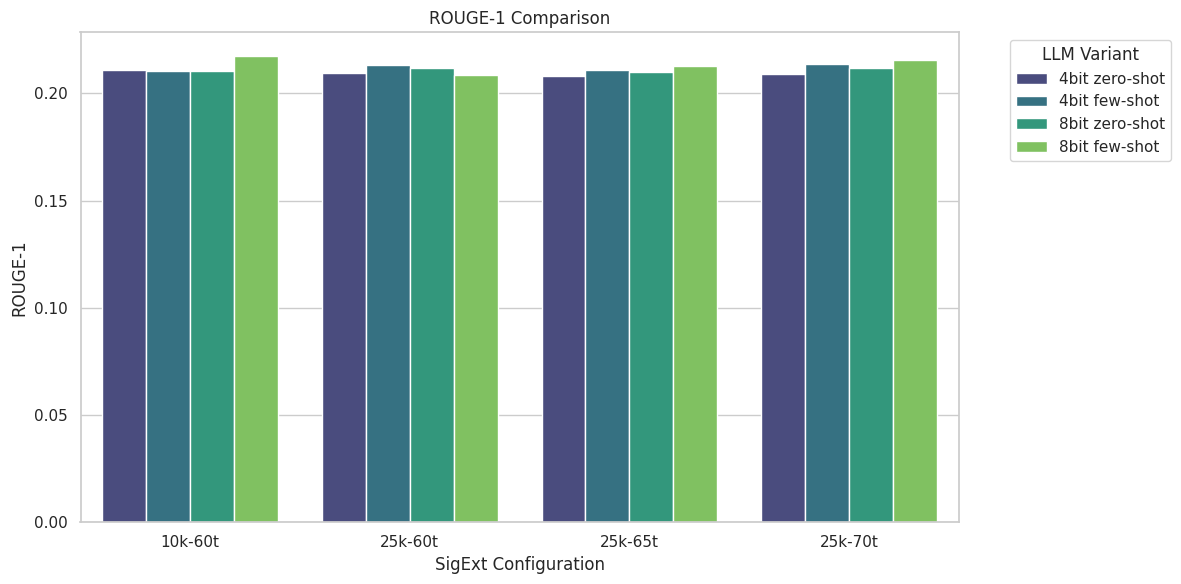

Saved: ./results/figures/comparison_kir.png


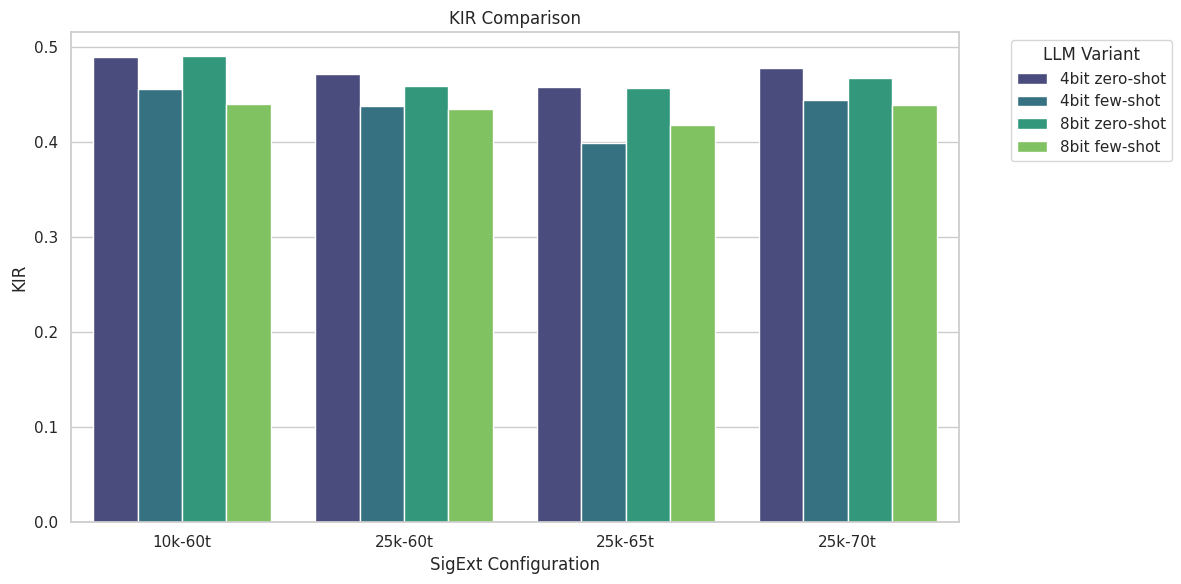

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze best configs
df = pd.DataFrame(all_results)

print("\n  BEST CONFIGURATIONS BY METRIC")
print("="*50)

# Best BERT Score
best_bert = df.loc[df['bert'].idxmax()]
print(f"\n  Best BERT Score: {best_bert['bert']:.4f}")
print(f"   Config: {best_bert['config']} | {best_bert['quant']} | {best_bert['shot_type']}")

# Best ROUGE-1
best_rouge = df.loc[df['rouge'].idxmax()]
print(f"\n  Best ROUGE-1: {best_rouge['rouge']:.4f}")
print(f"   Config: {best_rouge['config']} | {best_rouge['quant']} | {best_rouge['shot_type']}")

# Best KIR
best_kir = df.loc[df['kir'].idxmax()]
print(f"\n  Best KIR: {best_kir['kir']:.2%}")
print(f"   Config: {best_kir['config']} | {best_kir['quant']} | {best_kir['shot_type']}")

print("\n" + "="*50)

# Plotting
print("\n  GENERATING PLOTS...")

# Setup figures dir
figures_dir = os.path.join(GLOBAL_CONFIG["output_dir"], "figures")
os.makedirs(figures_dir, exist_ok=True)

# Prepare data for plotting
df['Variant'] = df['quant'] + " " + df['shot_type']
sns.set_theme(style="whitegrid")

metrics_map = {
    'bert': 'BERTScore',
    'rouge': 'ROUGE-1',
    'kir': 'KIR'
}

for metric_col, metric_name in metrics_map.items():
    plt.figure(figsize=(12, 6))
    
    sns.barplot(
        data=df,
        x='config',
        y=metric_col,
        hue='Variant',
        palette="viridis"
    )
    
    plt.title(f'{metric_name} Comparison')
    plt.xlabel('SigExt Configuration')
    plt.ylabel(metric_name)
    plt.legend(title='LLM Variant', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # Save
    save_path = os.path.join(figures_dir, f"comparison_{metric_col}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")
    
    # Show
    plt.show()